<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/pca_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute        import SimpleImputer

TRAIN_PATH = "/content/drive/MyDrive/Dengue Hematology Dataset_bd.csv"
TEST_PATH  = "/content/drive/MyDrive/paper1 data dengue detenction hematological data set.csv"
OUT        = "."   # output folder

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 1 — LOAD & PREPROCESS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_tr = pd.read_csv(TRAIN_PATH)
df_te = pd.read_csv(TEST_PATH)

df_tr = df_tr.drop(columns=["Sl.","ALT","AST","Unnamed: 12"], errors="ignore")
df_tr = df_tr.rename(columns={
    "Age (year)":"Age", "Dengue NS1":"Label",
    "Lymph %":"Lymph_pct", "Neut %":"Neut_pct"
})

test_drop = ["Hemoglobin(g/dl)","Monocytes(%)","Eosinophils(%)",
             "MCV(fl)","MCH(pg)","MCHC(g/dl)","RDW-CV(%)",
             "MPV(fl)","PDW(%)","PCT(%)"]
df_te = df_te.drop(columns=test_drop, errors="ignore")
df_te = df_te.rename(columns={
    "Gender":"Sex",
    "Total Platelet Count(/cumm)":"PLT",
    "Total WBC count(/cumm)":"WBC",
    "HCT(%)":"HCT",
    "Lymphocytes(%)":"Lymph_pct",
    "Neutrophils(%)":"Neut_pct",
    "Result":"Label"
})

FEATURES = ["Sex","Age","PLT","WBC","HCT","RBC","Lymph_pct","Neut_pct"]
N = len(FEATURES)

for df in [df_tr, df_te]:
    df["Label"] = df["Label"].str.strip().str.lower().map({"positive":1,"negative":0})
    df["Sex"]   = df["Sex"].str.strip().str.lower().map({"male":1,"female":0})

df_tr = df_tr[FEATURES+["Label"]].copy()
df_te = df_te[FEATURES+["Label"]].copy()

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(df_tr[FEATURES]))
X_test  = scaler.transform(imputer.transform(df_te[FEATURES]))
y_train = df_tr["Label"].values.astype(int)
y_test  = df_te["Label"].values.astype(int)

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 2 — PCA (fit on train only)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
pca_full = PCA(n_components=N, random_state=42)
pca_full.fit(X_train)
ev  = pca_full.explained_variance_ratio_
cev = np.cumsum(ev)
n95 = int(np.argmax(cev >= 0.95)) + 1

pca2 = PCA(n_components=2, random_state=42)
X_tr2 = pca2.fit_transform(X_train)
X_te2 = pca2.transform(X_test)

pca3 = PCA(n_components=3, random_state=42)
X_tr3 = pca3.fit_transform(X_train)
X_te3 = pca3.transform(X_test)

loadings = pd.DataFrame(
    pca_full.components_,
    columns=FEATURES,
    index=[f"PC{i+1}" for i in range(N)]
)

print("PCA Results:")
print(f"  PC1: {ev[0]*100:.2f}%  PC2: {ev[1]*100:.2f}%  PC3: {ev[2]*100:.2f}%")
print(f"  2D total: {(ev[0]+ev[1])*100:.2f}%   PCs for 95%: {n95}")
print(f"\nLoadings:\n{loadings.round(4).to_string()}")

PCA Results:
  PC1: 25.68%  PC2: 18.72%  PC3: 16.28%
  2D total: 44.40%   PCs for 95%: 7

Loadings:
        Sex     Age     PLT     WBC     HCT     RBC  Lymph_pct  Neut_pct
PC1 -0.0370  0.1131  0.2189  0.0686 -0.2391 -0.1272    -0.6555    0.6559
PC2  0.5358 -0.0874 -0.1572 -0.2140  0.5829  0.4543    -0.2143    0.2065
PC3  0.0825 -0.5531  0.6526  0.4733  0.1660  0.0749     0.0528   -0.0395
PC4  0.4439  0.5871 -0.0416  0.6526  0.0610 -0.1336     0.0734   -0.0610
PC5 -0.4532  0.2708  0.0401  0.2422 -0.0798  0.8089    -0.0186   -0.0018
PC6  0.3515  0.3364  0.6197 -0.4676 -0.3069  0.1656     0.1163   -0.1595
PC7 -0.4225  0.3775  0.3378 -0.1486  0.6858 -0.2673     0.0159    0.0279
PC8  0.0156  0.0020  0.0023 -0.0176 -0.0306  0.0281     0.7086    0.7040


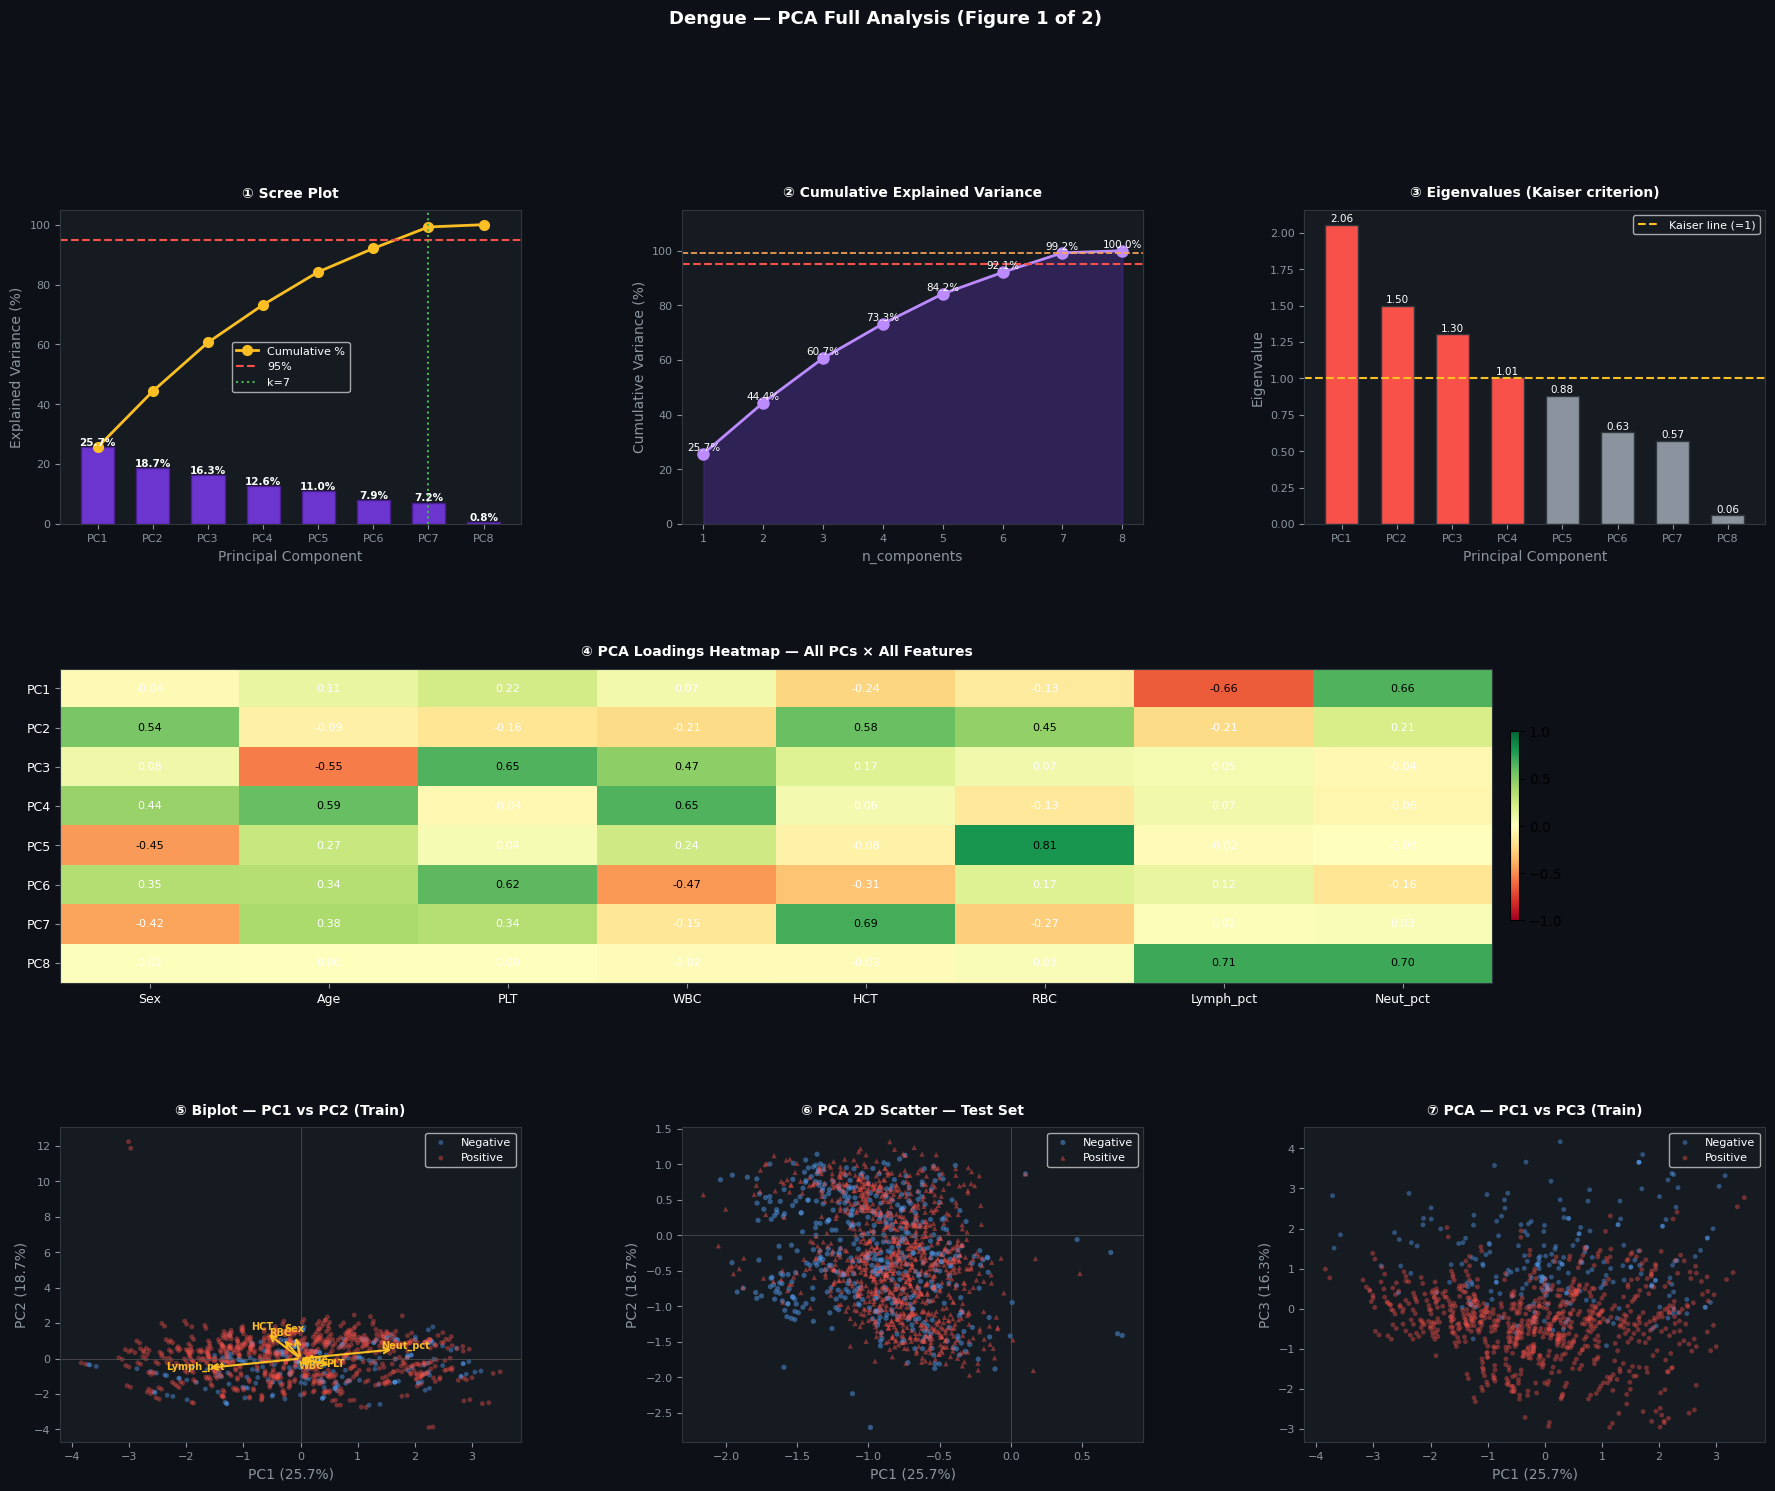

Figure 1 saved → dengue_pca_fig1.png


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 3 — FIGURE 1 (Scree + Heatmap + 2D Scatter + Biplot)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

%matplotlib inline
BG   = "#0d1117"
CARD = "#161b22"
NEG  = "#58a6ff"
POS  = "#f85149"

def sax(ax, title):
    ax.set_facecolor(CARD)
    ax.set_title(title, color="white", fontsize=10, fontweight="bold", pad=9)
    ax.tick_params(colors="#8b949e", labelsize=8)
    ax.xaxis.label.set_color("#8b949e")
    ax.yaxis.label.set_color("#8b949e")
    for sp in ax.spines.values():
        sp.set_edgecolor("#30363d")

fig1 = plt.figure(figsize=(22, 16), facecolor=BG)
gs1  = gridspec.GridSpec(3, 3, figure=fig1, hspace=0.46, wspace=0.35)

# ① Scree Plot
ax = fig1.add_subplot(gs1[0, 0])
sax(ax, "① Scree Plot")
ax.bar(range(1,N+1), ev*100, color="#7c3aed", alpha=0.85,
       edgecolor="#4c1d95", width=0.6)
ax.plot(range(1,N+1), cev*100, "o-", color="#fbbf24", lw=2, ms=7, label="Cumulative %")
ax.axhline(95, color=POS, ls="--", lw=1.5, label="95%")
ax.axvline(n95, color="#3fb950", ls=":", lw=1.5, label=f"k={n95}")
for i, e in enumerate(ev*100):
    ax.text(i+1, e+0.5, f"{e:.1f}%", ha="center", color="white", fontsize=7.5, fontweight="bold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_xticks(range(1,N+1))
ax.set_xticklabels([f"PC{i}" for i in range(1,N+1)], fontsize=8)
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)

# ② Cumulative Variance
ax = fig1.add_subplot(gs1[0, 1])
sax(ax, "② Cumulative Explained Variance")
ax.fill_between(range(1,N+1), cev*100, alpha=0.25, color="#7c3aed")
ax.plot(range(1,N+1), cev*100, "o-", color="#bc8cff", lw=2, ms=8)
ax.axhline(95, color=POS, ls="--", lw=1.5)
ax.axhline(99, color="#ffa657", ls="--", lw=1.2)
for i, c in enumerate(cev*100):
    ax.text(i+1, c+1.2, f"{c:.1f}%", ha="center", color="white", fontsize=7.5)
ax.set_xlabel("n_components")
ax.set_ylabel("Cumulative Variance (%)")
ax.set_xticks(range(1,N+1))
ax.set_ylim(0, 115)

# ③ Eigenvalues
ax = fig1.add_subplot(gs1[0, 2])
sax(ax, "③ Eigenvalues (Kaiser criterion)")
eigenvals = pca_full.explained_variance_
colors_e  = ["#f85149" if e >= 1 else "#8b949e" for e in eigenvals]
ax.bar(range(1,N+1), eigenvals, color=colors_e, edgecolor="#30363d", width=0.6)
ax.axhline(1, color="#fbbf24", ls="--", lw=1.5, label="Kaiser line (=1)")
for i, e in enumerate(eigenvals):
    ax.text(i+1, e+0.02, f"{e:.2f}", ha="center", color="white", fontsize=7.5)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Eigenvalue")
ax.set_xticks(range(1,N+1))
ax.set_xticklabels([f"PC{i}" for i in range(1,N+1)], fontsize=8)
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)

# ④ Loadings Heatmap
ax = fig1.add_subplot(gs1[1, :])
sax(ax, "④ PCA Loadings Heatmap — All PCs × All Features")
im = ax.imshow(loadings.values, cmap="RdYlGn", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(N))
ax.set_xticklabels(FEATURES, rotation=0, color="white", fontsize=9)
ax.set_yticks(range(N))
ax.set_yticklabels([f"PC{i+1}" for i in range(N)], color="white", fontsize=9)
for i in range(N):
    for j in range(N):
        val = loadings.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="black" if abs(val) > 0.45 else "white")
plt.colorbar(im, ax=ax, shrink=0.6, pad=0.01)

# ⑤ Biplot
ax = fig1.add_subplot(gs1[2, 0])
sax(ax, "⑤ Biplot — PC1 vs PC2 (Train)")
for cls, col, lbl in [(0,NEG,"Negative"),(1,POS,"Positive")]:
    m = y_train == cls
    ax.scatter(X_tr2[m,0], X_tr2[m,1], c=col, s=12, alpha=0.4, label=lbl, edgecolors="none")
scale = 2.5
for i, feat in enumerate(FEATURES):
    x = pca_full.components_[0, i] * scale
    y = pca_full.components_[1, i] * scale
    ax.annotate("", xy=(x,y), xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color="#fbbf24", lw=1.5))
    ax.text(x*1.12, y*1.12, feat, color="#fbbf24", fontsize=7, ha="center", fontweight="bold")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)
ax.axhline(0, color="#555", lw=0.5)
ax.axvline(0, color="#555", lw=0.5)

# ⑥ PCA 2D Test
ax = fig1.add_subplot(gs1[2, 1])
sax(ax, "⑥ PCA 2D Scatter — Test Set")
for cls, col, lbl, mk in [(0,NEG,"Negative","o"),(1,POS,"Positive","^")]:
    m = y_test == cls
    ax.scatter(X_te2[m,0], X_te2[m,1], c=col, s=14, marker=mk,
               alpha=0.45, label=lbl, edgecolors="none")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)
ax.axhline(0, color="#555", lw=0.5)
ax.axvline(0, color="#555", lw=0.5)

# ⑦ PC1 vs PC3
ax = fig1.add_subplot(gs1[2, 2])
sax(ax, "⑦ PCA — PC1 vs PC3 (Train)")
for cls, col, lbl in [(0,NEG,"Negative"),(1,POS,"Positive")]:
    m = y_train == cls
    ax.scatter(X_tr3[m,0], X_tr3[m,2], c=col, s=12, alpha=0.4, label=lbl, edgecolors="none")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC3 ({ev[2]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)

plt.suptitle("Dengue — PCA Full Analysis (Figure 1 of 2)",
             color="white", fontsize=13, fontweight="bold", y=1.005)
plt.savefig(f"{OUT}/dengue_pca_fig1.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
plt.close()
print("Figure 1 saved → dengue_pca_fig1.png")

In [8]:
# STEP 5 — SAVE PCA DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
pd.DataFrame(X_tr2, columns=["PC1","PC2"]).assign(Label=y_train)\
  .to_csv(f"{OUT}/train_pca2d.csv", index=False)
pd.DataFrame(X_te2, columns=["PC1","PC2"]).assign(Label=y_test)\
  .to_csv(f"{OUT}/test_pca2d.csv", index=False)
loadings.round(6).to_csv(f"{OUT}/pca_loadings.csv")
print("CSVs saved.")

CSVs saved.


  Overall centroid distance  : 0.9100
  Negative class distance    : 1.1970
  Positive class distance    : 0.8553


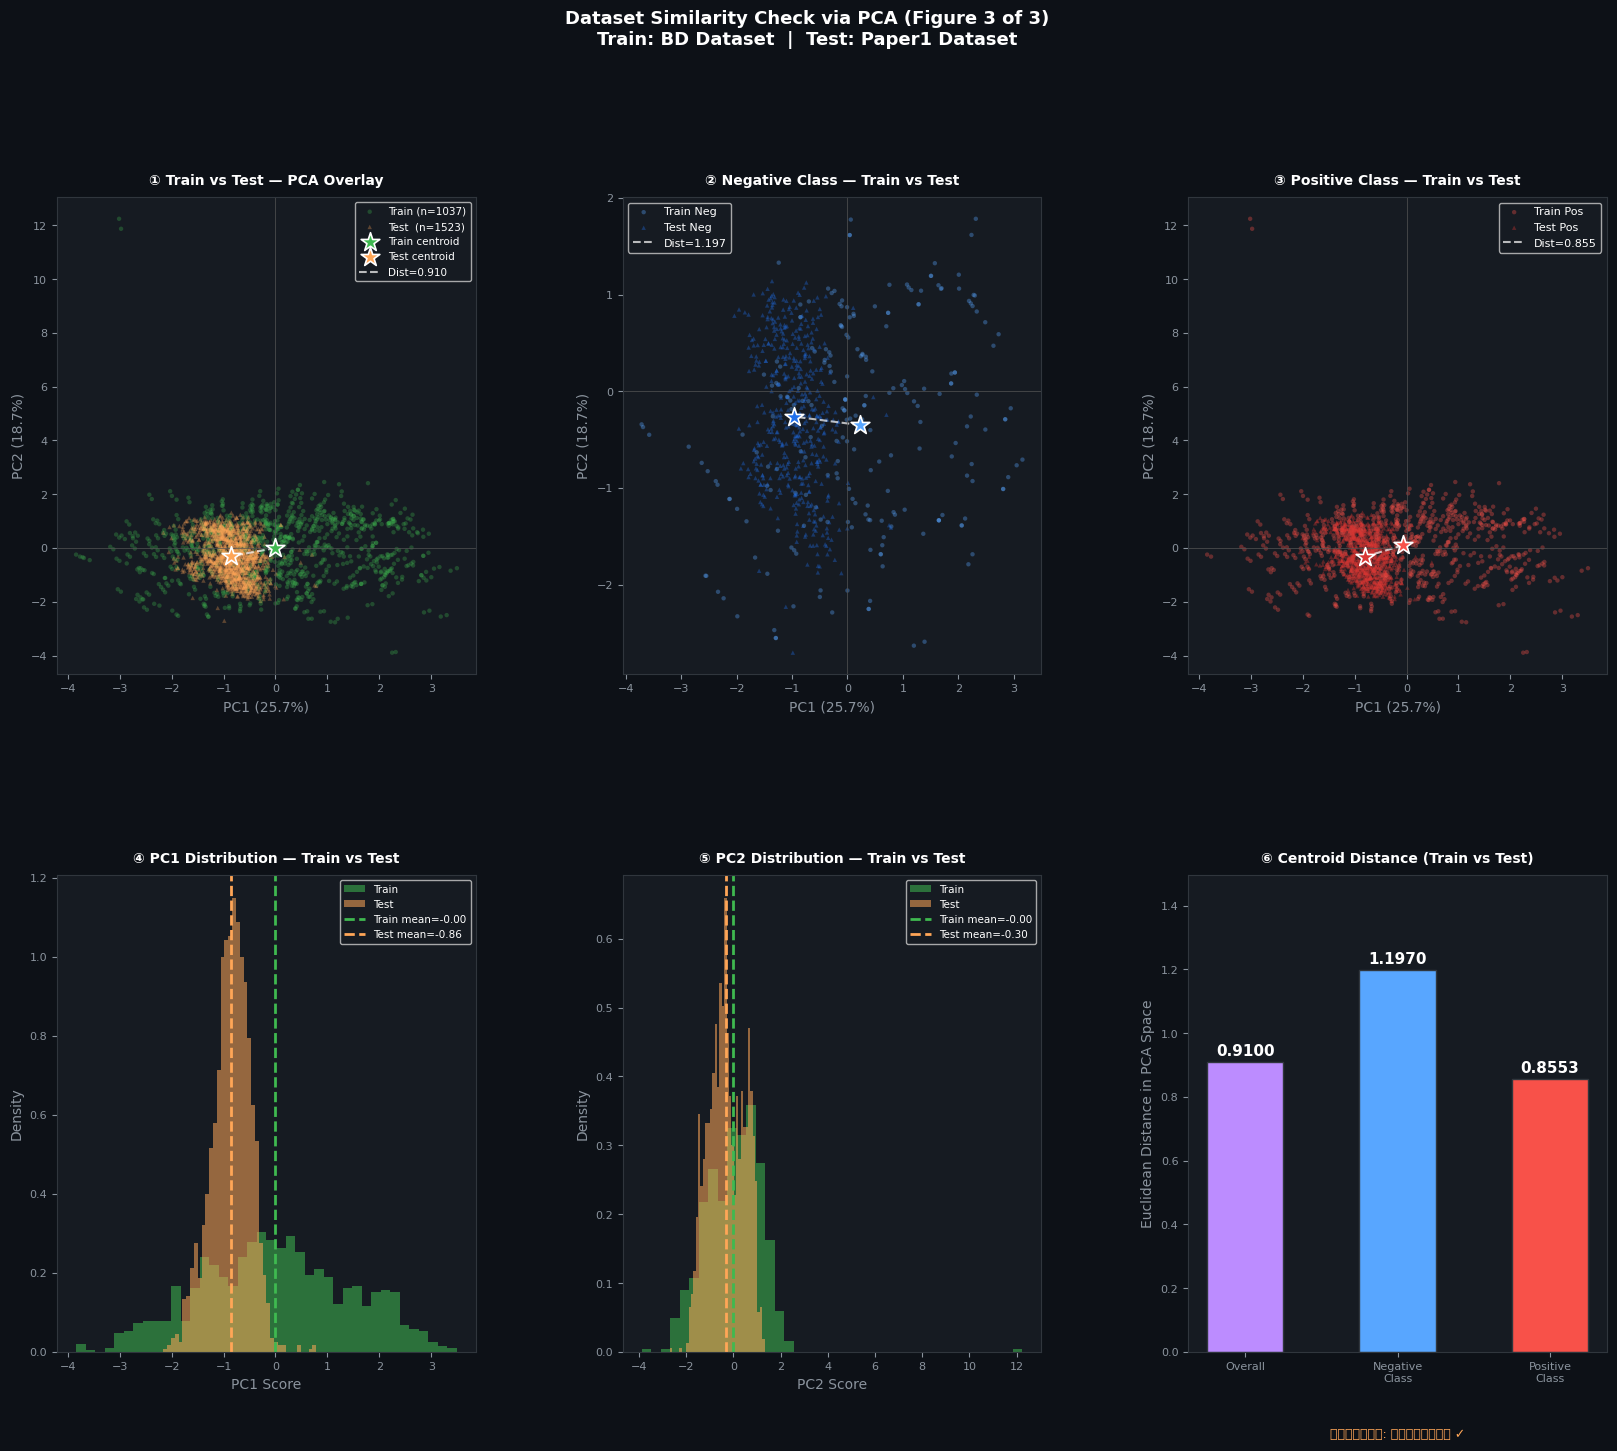

Figure 3 saved.


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FIGURE 3 — Dataset Similarity Check via PCA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from scipy.spatial.distance import cdist

# Centroid calculations
tr_centroid = X_tr2.mean(axis=0)
te_centroid = X_te2.mean(axis=0)
centroid_dist = np.linalg.norm(tr_centroid - te_centroid)

tr_neg = X_tr2[y_train==0].mean(axis=0)
tr_pos = X_tr2[y_train==1].mean(axis=0)
te_neg = X_te2[y_test==0].mean(axis=0)
te_pos = X_te2[y_test==1].mean(axis=0)

neg_dist = np.linalg.norm(tr_neg - te_neg)
pos_dist = np.linalg.norm(tr_pos - te_pos)

print("=" * 50)
print(f"  Overall centroid distance  : {centroid_dist:.4f}")
print(f"  Negative class distance    : {neg_dist:.4f}")
print(f"  Positive class distance    : {pos_dist:.4f}")
print("=" * 50)

fig3 = plt.figure(figsize=(20, 15), facecolor=BG)
gs3  = gridspec.GridSpec(2, 3, figure=fig3, hspace=0.42, wspace=0.35)

# ① Train vs Test overlay
ax = fig3.add_subplot(gs3[0, 0])
sax(ax, "① Train vs Test — PCA Overlay")
ax.scatter(X_tr2[:,0], X_tr2[:,1], c="#3fb950", s=10,
           alpha=0.3, label=f"Train (n={len(X_tr2)})", edgecolors="none")
ax.scatter(X_te2[:,0], X_te2[:,1], c="#ffa657", s=10,
           alpha=0.3, label=f"Test  (n={len(X_te2)})",
           edgecolors="none", marker="^")
ax.scatter(*tr_centroid, c="#3fb950", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2, label="Train centroid")
ax.scatter(*te_centroid, c="#ffa657", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2, label="Test centroid")
ax.plot([tr_centroid[0], te_centroid[0]],
        [tr_centroid[1], te_centroid[1]],
        "--", color="white", lw=1.5, alpha=0.7,
        label=f"Dist={centroid_dist:.3f}")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=7.5)
ax.axhline(0, color="#555", lw=0.5)
ax.axvline(0, color="#555", lw=0.5)

# ② Negative class — Train vs Test
ax = fig3.add_subplot(gs3[0, 1])
sax(ax, "② Negative Class — Train vs Test")
ax.scatter(X_tr2[y_train==0, 0], X_tr2[y_train==0, 1],
           c="#58a6ff", s=10, alpha=0.35, label="Train Neg", edgecolors="none")
ax.scatter(X_te2[y_test==0,  0], X_te2[y_test==0,  1],
           c="#1f6feb", s=10, alpha=0.35, label="Test Neg",
           edgecolors="none", marker="^")
ax.scatter(*tr_neg, c="#58a6ff", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2)
ax.scatter(*te_neg, c="#1f6feb", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2)
ax.plot([tr_neg[0], te_neg[0]], [tr_neg[1], te_neg[1]],
        "--", color="white", lw=1.5, alpha=0.7,
        label=f"Dist={neg_dist:.3f}")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)
ax.axhline(0, color="#555", lw=0.5)
ax.axvline(0, color="#555", lw=0.5)

# ③ Positive class — Train vs Test
ax = fig3.add_subplot(gs3[0, 2])
sax(ax, "③ Positive Class — Train vs Test")
ax.scatter(X_tr2[y_train==1, 0], X_tr2[y_train==1, 1],
           c="#f85149", s=10, alpha=0.35, label="Train Pos", edgecolors="none")
ax.scatter(X_te2[y_test==1,  0], X_te2[y_test==1,  1],
           c="#da3633", s=10, alpha=0.35, label="Test Pos",
           edgecolors="none", marker="^")
ax.scatter(*tr_pos, c="#f85149", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2)
ax.scatter(*te_pos, c="#da3633", s=200, marker="*",
           zorder=5, edgecolors="white", lw=1.2)
ax.plot([tr_pos[0], te_pos[0]], [tr_pos[1], te_pos[1]],
        "--", color="white", lw=1.5, alpha=0.7,
        label=f"Dist={pos_dist:.3f}")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=8)
ax.axhline(0, color="#555", lw=0.5)
ax.axvline(0, color="#555", lw=0.5)

# ④ PC1 histogram
ax = fig3.add_subplot(gs3[1, 0])
sax(ax, "④ PC1 Distribution — Train vs Test")
ax.hist(X_tr2[:,0], bins=40, color="#3fb950", alpha=0.55,
        density=True, label="Train")
ax.hist(X_te2[:,0], bins=40, color="#ffa657", alpha=0.55,
        density=True, label="Test")
ax.axvline(tr_centroid[0], color="#3fb950", lw=2, ls="--",
           label=f"Train mean={tr_centroid[0]:.2f}")
ax.axvline(te_centroid[0], color="#ffa657", lw=2, ls="--",
           label=f"Test mean={te_centroid[0]:.2f}")
ax.set_xlabel("PC1 Score")
ax.set_ylabel("Density")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=7.5)

# ⑤ PC2 histogram
ax = fig3.add_subplot(gs3[1, 1])
sax(ax, "⑤ PC2 Distribution — Train vs Test")
ax.hist(X_tr2[:,1], bins=40, color="#3fb950", alpha=0.55,
        density=True, label="Train")
ax.hist(X_te2[:,1], bins=40, color="#ffa657", alpha=0.55,
        density=True, label="Test")
ax.axvline(tr_centroid[1], color="#3fb950", lw=2, ls="--",
           label=f"Train mean={tr_centroid[1]:.2f}")
ax.axvline(te_centroid[1], color="#ffa657", lw=2, ls="--",
           label=f"Test mean={te_centroid[1]:.2f}")
ax.set_xlabel("PC2 Score")
ax.set_ylabel("Density")
ax.legend(facecolor=CARD, labelcolor="white", fontsize=7.5)

# ⑥ Distance bar
ax = fig3.add_subplot(gs3[1, 2])
sax(ax, "⑥ Centroid Distance (Train vs Test)")
categories = ["Overall", "Negative\nClass", "Positive\nClass"]
distances  = [centroid_dist, neg_dist, pos_dist]
colors_b   = ["#bc8cff", "#58a6ff", "#f85149"]
bars = ax.bar(categories, distances, color=colors_b,
              edgecolor="#30363d", width=0.5)
for bar, v in zip(bars, distances):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
            f"{v:.4f}", ha="center", va="bottom",
            color="white", fontsize=11, fontweight="bold")
ax.set_ylabel("Euclidean Distance in PCA Space")
ax.set_ylim(0, max(distances)*1.25)
closer = "কাছাকাছি ✓" if centroid_dist < 1.0 else "দূরে — distribution shift আছে"
ax.text(0.5, -0.18, f"মন্তব্য: {closer}",
        ha="center", transform=ax.transAxes,
        color="#ffa657", fontsize=9)

plt.suptitle("Dataset Similarity Check via PCA (Figure 3 of 3)\n"
             "Train: BD Dataset  |  Test: Paper1 Dataset",
             color="white", fontsize=13, fontweight="bold", y=1.005)

plt.savefig("dengue_pca_fig3.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figure 3 saved.")